# Equal-weight forecast ensemble: lgb_rich + xgb_rich + log-HAR(GVZ+macro) — 6y, MCS

Equal-weight ensemble of three next-day gold-RV forecasters, combining **only the point
forecasts** (in levels): `f_ens = (f_har18 + f_xgb_rich + f_lgb_rich) / 3`.

- **HAR** (`har_run18` = HAR + log_GVZ + macro): log-OLS, Duan smearing, **recency δ=0.999**.
- **xgb_rich / lgb_rich**: custom-QLIKE gradient boosting, grid + 4-fold walk-forward CV,
  early stopping, bi-weekly refit — **NO recency weights (δ=1.0)**, **no Optuna**.
- Features (both trees, `feats_rich`): `[x_d,x_w,x_m,log_GVZ,log_RV_crude,log_RV_ES,macro]`.
- Whole program capped at **3 threads**. Everything scored by QLIKE in levels on the same
  common OOS, then a 6-model MCS (ensemble + 3 components + har_run19 + har_run20).

In [1]:
# ===========================================================================
# Cell 1 — Thread caps (<=3), imports, data, constants
# ===========================================================================
import os
for _v in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ[_v] = "3"                      # cap BLAS/OpenMP BEFORE numpy import
import importlib.util, subprocess, time, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

def _import_lightgbm():
    try:
        import lightgbm as lgb; return lgb
    except OSError:
        import sklearn
        sk  = os.path.join(os.path.dirname(sklearn.__file__), ".dylibs")
        lib = os.path.join(os.path.dirname(importlib.util.find_spec("lightgbm").origin),
                           "lib", "lib_lightgbm.dylib")
        subprocess.run(["install_name_tool", "-add_rpath", sk, lib], check=False)
        import lightgbm as lgb; return lgb
lgb = _import_lightgbm()
from arch.bootstrap import MCS

data = pd.read_parquet("merged_RV_GVZ_with_macro_event.parquet")
rv = data["RV_gold"].astype(float)

TRADING_DAYS = 252
WINDOW_YEARS = np.arange(1.0, 7.001, 0.25)                 # reference grid (defines common OOS)
WINDOWS = [int(round(yr * TRADING_DAYS)) for yr in WINDOW_YEARS]
WINDOW = 6 * TRADING_DAYS                                  # 1512 days = 6y
DELTA_HAR = 0.999                                         # HAR keeps recency weighting
DELTA_GBM = 1.0                                           # trees: NO recency weights
REFIT_EVERY = 10                                          # bi-weekly refit (trading days)
EPS = 1e-6
N_THREADS = 3                                             # hard cap for the whole program

print(f"RV_gold: {len(rv)} obs, {rv.index.min().date()} .. {rv.index.max().date()}")
print(f"WINDOW={WINDOW} (6y) | DELTA_HAR={DELTA_HAR} | DELTA_GBM={DELTA_GBM} (no recency) | "
      f"N_THREADS={N_THREADS} | xgb {xgb.__version__} | lgb {lgb.__version__}")

RV_gold: 4015 obs, 2010-06-08 .. 2026-05-29
WINDOW=1512 (6y) | DELTA_HAR=0.999 | DELTA_GBM=1.0 (no recency) | N_THREADS=3 | xgb 3.2.0 | lgb 4.6.0


In [2]:
# ===========================================================================
# Cell 2 — Design tables (mirror the XGB / LGB / HAR notebooks)
# ===========================================================================
for col in ["RV_gold", "GVZ_close", "RV_ES", "RV_crude"]:
    assert (data[col] > 0).all(), f"{col} has non-positive values; log undefined"

x = np.log(rv)

def build_log_design(extra_cols):
    df = pd.DataFrame(index=rv.index)
    df["x_d"] = x
    df["x_w"] = x.rolling(5).mean()
    df["x_m"] = x.rolling(22).mean()
    for name, series in extra_cols.items():
        df[name] = series.reindex(rv.index)
    df["y_log"]   = x.shift(-1)
    df["y_level"] = rv.shift(-1)
    return df.dropna()

log_gvz   = np.log(data["GVZ_close"])
log_spx   = np.log(data["RV_ES"])
log_crude = np.log(data["RV_crude"])
macro     = data["macro_event"].shift(-1).astype(float)

d_gvz_macro       = build_log_design({"log_GVZ": log_gvz, "macro": macro})
d_crude_gvz_macro = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude, "macro": macro})
d_spx_gvz_macro   = build_log_design({"log_GVZ": log_gvz, "log_RV_ES": log_spx, "macro": macro})
d_all_macro       = build_log_design({"log_GVZ": log_gvz, "log_RV_crude": log_crude,
                                      "log_RV_ES": log_spx, "macro": macro})
for d in (d_crude_gvz_macro, d_spx_gvz_macro, d_all_macro):
    assert d_gvz_macro.index.equals(d.index)
print("designs rows:", len(d_gvz_macro), "| rich cols:", list(d_all_macro.columns))

designs rows: 3993 | rich cols: ['x_d', 'x_w', 'x_m', 'log_GVZ', 'log_RV_crude', 'log_RV_ES', 'macro', 'y_log', 'y_level']


In [3]:
# ===========================================================================
# Cell 3 — Helpers + HAR forecast series (delta=0.999)
# ===========================================================================
START_DATE = d_gvz_macro.index[max(WINDOWS)]   # common OOS gate (same as source notebooks)

def _recency_weights(n, delta):
    if delta >= 1.0:
        return np.ones(n)
    ages = np.arange(n)[::-1]
    w = delta ** ages
    return w * (n / w.sum())

def _qlike(actual, forecast, eps=EPS):
    f = np.maximum(forecast, eps)
    r = actual / f
    return r - np.log(r) - 1.0, int((forecast <= eps).sum())

def rolling_log_ols_forecast_series(design, feat_cols, window=WINDOW, delta=DELTA_HAR, start_date=None):
    """Vectorised weighted-OLS log-HAR; returns the per-day LEVEL forecast Series (Duan smearing)."""
    if start_date is None:
        start_date = START_DATE
    X = np.column_stack([np.ones(len(design)), design[feat_cols].to_numpy()])
    yl = design["y_log"].to_numpy(); idx = design.index; N, p = X.shape
    t_oos = np.arange(window, N)[idx[window:] >= start_date]; starts = t_oos - window
    Xwins = np.lib.stride_tricks.sliding_window_view(X, window, axis=0)[starts].transpose(0, 2, 1)
    ywins = np.lib.stride_tricks.sliding_window_view(yl, window)[starts]
    w = _recency_weights(window, delta); sw = np.sqrt(w)
    Xs = Xwins * sw[None, :, None]; ys = ywins * sw[None, :]
    beta = np.linalg.solve(np.einsum("nwi,nwj->nij", Xs, Xs), np.einsum("nwi,nw->ni", Xs, ys))
    fitted = np.einsum("nwp,np->nw", Xwins, beta)
    smear = np.einsum("nw,w->n", np.exp(ywins - fitted), w) / w.sum()
    fc = np.exp(np.einsum("np,np->n", X[t_oos], beta)) * smear
    return pd.Series(fc, index=idx[t_oos], name="forecast")

f_har18 = rolling_log_ols_forecast_series(d_gvz_macro,       ["x_d", "x_w", "x_m", "log_GVZ", "macro"])
f_har19 = rolling_log_ols_forecast_series(d_spx_gvz_macro,   ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_ES", "macro"])
f_har20 = rolling_log_ols_forecast_series(d_crude_gvz_macro, ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude", "macro"])
actual = d_gvz_macro["y_level"].reindex(f_har18.index)
print(f"Common OOS: {f_har18.index.min().date()} .. {f_har18.index.max().date()}  (n={len(f_har18)})")
print("HAR mean QLIKE:", {k: round(float(_qlike(actual.values, f.values)[0].mean()), 6)
                          for k, f in [("har_run18", f_har18), ("har_run19", f_har19), ("har_run20", f_har20)]})

Common OOS: 2017-07-11 .. 2026-05-28  (n=2229)
HAR mean QLIKE: {'har_run18': 0.027551, 'har_run19': 0.027546, 'har_run20': 0.027481}


In [4]:
# ===========================================================================
# Cell 4 — XGBoost xgb_rich forecast series (custom QLIKE, WF-CV, NO recency, <=3 threads)
# ===========================================================================
MARGIN_CLIP = (-2.0, 8.0)
ESR, CAP = 30, 500
WF_EDGES = [0.20, 0.40, 0.60, 0.80, 1.00]                  # 4 expanding walk-forward folds
XGB_GRID = [dict(max_depth=md, eta=lr, subsample=0.8, colsample_bytree=0.8,
                 min_child_weight=5, reg_lambda=1.0, tree_method="hist", nthread=N_THREADS)
            for md, lr in itertools.product([2, 3, 4], [0.03, 0.1])]

def _xgb_make_obj(w):
    def obj(preds, dtrain):
        y = dtrain.get_label(); f = np.exp(np.clip(preds, *MARGIN_CLIP))
        return w * (1.0 - y / f), w * (y / f)
    return obj

def _xgb_qlike_feval(preds, dmat):
    y = dmat.get_label(); f = np.maximum(np.exp(np.clip(preds, *MARGIN_CLIP)), EPS); r = y / f
    return "qlike", float(np.mean(r - np.log(r) - 1.0))

def _xgb_fit_window(Xw, yw, delta):
    n = len(Xw); w_full = _recency_weights(n, delta)
    edges = [int(round(f * n)) for f in WF_EDGES]
    folds = [(0, edges[k], edges[k + 1]) for k in range(4)]
    chosen = []
    for tr0, v0, v1 in folds:
        Xtr, ytr = Xw[tr0:v0], yw[tr0:v0]; Xvl, yvl = Xw[v0:v1], yw[v0:v1]
        wtr = w_full[tr0:v0] * ((v0 - tr0) / w_full[tr0:v0].sum())
        m0 = np.average(np.log(ytr), weights=wtr)
        dtr = xgb.DMatrix(Xtr, label=ytr); dtr.set_base_margin(np.full(len(ytr), m0))
        dvl = xgb.DMatrix(Xvl, label=yvl); dvl.set_base_margin(np.full(len(yvl), m0))
        fb = None
        for params in XGB_GRID:
            bst = xgb.train(params, dtr, num_boost_round=CAP, obj=_xgb_make_obj(wtr),
                            custom_metric=_xgb_qlike_feval, evals=[(dvl, "val")],
                            early_stopping_rounds=ESR, maximize=False, verbose_eval=False)
            if fb is None or bst.best_score < fb[0]:
                fb = (bst.best_score, params, bst.best_iteration)
        chosen.append(fb)
    m0f = np.average(np.log(yw), weights=w_full)
    dall = xgb.DMatrix(Xw, label=yw); dall.set_base_margin(np.full(n, m0f))
    boosters = [xgb.train(p, dall, num_boost_round=max(int(bi) + 1, 1),
                          obj=_xgb_make_obj(w_full), verbose_eval=False)
                for (_, p, bi) in chosen]
    return boosters, m0f

def _xgb_predict_ens(boosters, m0f, Xrows):
    fs = []
    for bst in boosters:
        d = xgb.DMatrix(Xrows); d.set_base_margin(np.full(len(Xrows), m0f))
        fs.append(np.exp(np.clip(bst.predict(d), *MARGIN_CLIP)))
    return np.mean(fs, axis=0)

def rolling_xgb_cv_forecast_series(design, feat_cols, window=WINDOW, delta=DELTA_GBM,
                                   refit_every=REFIT_EVERY, start_date=None, label=""):
    if start_date is None:
        start_date = START_DATE
    Xall = design[feat_cols].to_numpy(); lvl = design["y_level"].to_numpy(); idx = design.index
    N = len(design); t_oos = np.arange(window, N)[idx[window:] >= start_date]
    fc = np.empty(len(t_oos)); t0 = time.time()
    for p0 in range(0, len(t_oos), refit_every):
        r = t_oos[p0]
        boosters, m0f = _xgb_fit_window(Xall[r - window:r], lvl[r - window:r], delta)
        block = t_oos[p0:p0 + refit_every]
        fc[p0:p0 + refit_every] = _xgb_predict_ens(boosters, m0f, Xall[block])
        if (p0 // refit_every + 1) % 50 == 0:
            print(f"  [{label}] refit {p0 // refit_every + 1}/{int(np.ceil(len(t_oos)/refit_every))} ({time.time()-t0:.0f}s)")
    print(f"[{label}] done elapsed={time.time()-t0:.0f}s")
    return pd.Series(fc, index=idx[t_oos], name="forecast")

feats_rich = ["x_d", "x_w", "x_m", "log_GVZ", "log_RV_crude", "log_RV_ES", "macro"]
f_xgb_rich = rolling_xgb_cv_forecast_series(d_all_macro, feats_rich, label="xgb_rich")
print("xgb_rich mean QLIKE:", round(float(_qlike(actual.values, f_xgb_rich.values)[0].mean()), 6))

  [xgb_rich] refit 50/223 (45s)


  [xgb_rich] refit 100/223 (93s)


  [xgb_rich] refit 150/223 (142s)


  [xgb_rich] refit 200/223 (206s)


[xgb_rich] done elapsed=231s
xgb_rich mean QLIKE: 0.030042


In [5]:
# ===========================================================================
# Cell 5 — LightGBM lgb_rich forecast series (custom QLIKE, WF-CV, NO recency, <=3 threads)
# ===========================================================================
LGB_DEPTH_LEAVES = [(2, 4), (3, 7), (4, 15)]
LGB_MIN_DATA     = [20, 50, 100]
LGB_GRID = [dict(max_depth=md, num_leaves=nl, min_data_in_leaf=mdl, learning_rate=0.05,
                 feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
                 verbosity=-1, num_threads=N_THREADS, seed=0)
            for (md, nl) in LGB_DEPTH_LEAVES for mdl in LGB_MIN_DATA]
LGB_DS = {"feature_pre_filter": False}

def _lgb_make_obj(w):
    def obj(preds, ds):
        y = ds.get_label(); f = np.exp(np.clip(preds, *MARGIN_CLIP))
        return w * (1.0 - y / f), w * (y / f)
    return obj

def _lgb_qlike_feval(preds, ds):
    y = ds.get_label(); f = np.maximum(np.exp(np.clip(preds, *MARGIN_CLIP)), EPS); r = y / f
    return "qlike", float(np.mean(r - np.log(r) - 1.0)), False

def _lgb_fit_window(Xw, yw, delta):
    n = len(Xw); w_full = _recency_weights(n, delta)
    edges = [int(round(f * n)) for f in WF_EDGES]
    folds = [(0, edges[k], edges[k + 1]) for k in range(4)]
    chosen = []
    for tr0, v0, v1 in folds:
        Xtr, ytr = Xw[tr0:v0], yw[tr0:v0]; Xvl, yvl = Xw[v0:v1], yw[v0:v1]
        wtr = w_full[tr0:v0] * ((v0 - tr0) / w_full[tr0:v0].sum())
        m0 = np.average(np.log(ytr), weights=wtr)
        dtr = lgb.Dataset(Xtr, label=ytr, init_score=np.full(len(ytr), m0),
                          params=LGB_DS, free_raw_data=False)
        dvl = lgb.Dataset(Xvl, label=yvl, init_score=np.full(len(yvl), m0),
                          reference=dtr, params=LGB_DS, free_raw_data=False)
        fb = None
        for params in LGB_GRID:
            bst = lgb.train(dict(params, objective=_lgb_make_obj(wtr)), dtr, num_boost_round=CAP,
                            valid_sets=[dvl], valid_names=["val"], feval=_lgb_qlike_feval,
                            callbacks=[lgb.early_stopping(ESR, verbose=False), lgb.log_evaluation(0)])
            sc = bst.best_score["val"]["qlike"]
            if fb is None or sc < fb[0]:
                fb = (sc, params, bst.best_iteration)
        chosen.append(fb)
    m0f = np.average(np.log(yw), weights=w_full)
    dall = lgb.Dataset(Xw, label=yw, init_score=np.full(n, m0f), params=LGB_DS, free_raw_data=False)
    boosters = [lgb.train(dict(p, objective=_lgb_make_obj(w_full)), dall,
                          num_boost_round=max(int(bi), 1), callbacks=[lgb.log_evaluation(0)])
                for (_, p, bi) in chosen]
    return boosters, m0f

def _lgb_predict_ens(boosters, m0f, Xrows):
    fs = [np.exp(np.clip(m0f + bst.predict(Xrows, raw_score=True), *MARGIN_CLIP)) for bst in boosters]
    return np.mean(fs, axis=0)

def rolling_lgb_cv_forecast_series(design, feat_cols, window=WINDOW, delta=DELTA_GBM,
                                   refit_every=REFIT_EVERY, start_date=None, label=""):
    if start_date is None:
        start_date = START_DATE
    Xall = design[feat_cols].to_numpy(); lvl = design["y_level"].to_numpy(); idx = design.index
    N = len(design); t_oos = np.arange(window, N)[idx[window:] >= start_date]
    fc = np.empty(len(t_oos)); t0 = time.time()
    for p0 in range(0, len(t_oos), refit_every):
        r = t_oos[p0]
        boosters, m0f = _lgb_fit_window(Xall[r - window:r], lvl[r - window:r], delta)
        block = t_oos[p0:p0 + refit_every]
        fc[p0:p0 + refit_every] = _lgb_predict_ens(boosters, m0f, Xall[block])
        if (p0 // refit_every + 1) % 50 == 0:
            print(f"  [{label}] refit {p0 // refit_every + 1}/{int(np.ceil(len(t_oos)/refit_every))} ({time.time()-t0:.0f}s)")
    print(f"[{label}] done elapsed={time.time()-t0:.0f}s")
    return pd.Series(fc, index=idx[t_oos], name="forecast")

f_lgb_rich = rolling_lgb_cv_forecast_series(d_all_macro, feats_rich, label="lgb_rich")
print("lgb_rich mean QLIKE:", round(float(_qlike(actual.values, f_lgb_rich.values)[0].mean()), 6))

  [lgb_rich] refit 50/223 (19s)


  [lgb_rich] refit 100/223 (44s)


  [lgb_rich] refit 150/223 (66s)


  [lgb_rich] refit 200/223 (86s)


[lgb_rich] done elapsed=95s
lgb_rich mean QLIKE: 0.030672


In [6]:
# ===========================================================================
# Cell 6 — Equal-weight ensemble + per-day QLIKE for all 6 models
# ===========================================================================
forecasts = pd.DataFrame({
    "har_run18": f_har18, "har_run19": f_har19, "har_run20": f_har20,
    "xgb_rich": f_xgb_rich, "lgb_rich": f_lgb_rich,
}).dropna()
# equal-weight ensemble of ONLY the three chosen models' forecasts
forecasts["ensemble_eq"] = forecasts[["har_run18", "xgb_rich", "lgb_rich"]].mean(axis=1)
assert forecasts.notna().all().all()
act = actual.reindex(forecasts.index).values

losses = pd.DataFrame({m: _qlike(act, forecasts[m].values)[0] for m in forecasts.columns},
                      index=forecasts.index)
assert losses.notna().all().all()
forecasts.to_parquet("ensemble_forecasts_6y.parquet")
losses.to_parquet("ensemble_losses_6y.parquet")

pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print(f"OOS days: {len(losses)}  ({losses.index.min().date()} .. {losses.index.max().date()})\n")
print("Mean QLIKE by model (lower = better):")
print(losses.mean().sort_values().rename("mean_qlike").to_frame().to_string())

OOS days: 2229  (2017-07-11 .. 2026-05-28)

Mean QLIKE by model (lower = better):
             mean_qlike
har_run20      0.027481
har_run19      0.027546
har_run18      0.027551
ensemble_eq    0.028636
xgb_rich       0.030042
lgb_rich       0.030672


In [7]:
# ===========================================================================
# Cell 7 — Model Confidence Set (6 models: ensemble + components + HAR baselines)
# ===========================================================================
mcs = MCS(losses, size=0.05, reps=10000, block_size=None,
          method="R", bootstrap="stationary", seed=42)
mcs.compute()
pv = mcs.pvalues["Pvalue"]
mcs_results = (pd.DataFrame({"mean_qlike": losses.mean(), "mcs_pvalue": pv})
               .assign(in_mcs=lambda d: d["mcs_pvalue"] > 0.05)
               .sort_values("mean_qlike"))
mcs_results.to_parquet("mcs_ensemble_6y.parquet")
print("Model Confidence Set (size=0.05, reps=10000, stationary bootstrap):\n")
print(mcs_results.to_string())
print(f"\nBest: {mcs_results.index[0]}")
print(f"In 5% MCS: {list(mcs_results.index[mcs_results['in_mcs']])}")
print(f"Excluded:  {list(mcs_results.index[~mcs_results['in_mcs']])}")
mcs_results

Model Confidence Set (size=0.05, reps=10000, stationary bootstrap):

             mean_qlike  mcs_pvalue  in_mcs
har_run20      0.027481    1.000000    True
har_run19      0.027546    0.550000    True
har_run18      0.027551    0.550000    True
ensemble_eq    0.028636    0.233400    True
xgb_rich       0.030042    0.022300   False
lgb_rich       0.030672    0.083000    True

Best: har_run20
In 5% MCS: ['har_run20', 'har_run19', 'har_run18', 'ensemble_eq', 'lgb_rich']
Excluded:  ['xgb_rich']


,mean_qlike,mcs_pvalue,in_mcs
har_run20,0.027481,1.000000,True
har_run19,0.027546,0.550000,True
har_run18,0.027551,0.550000,True
ensemble_eq,0.028636,0.233400,True
xgb_rich,0.030042,0.022300,False
lgb_rich,0.030672,0.083000,True


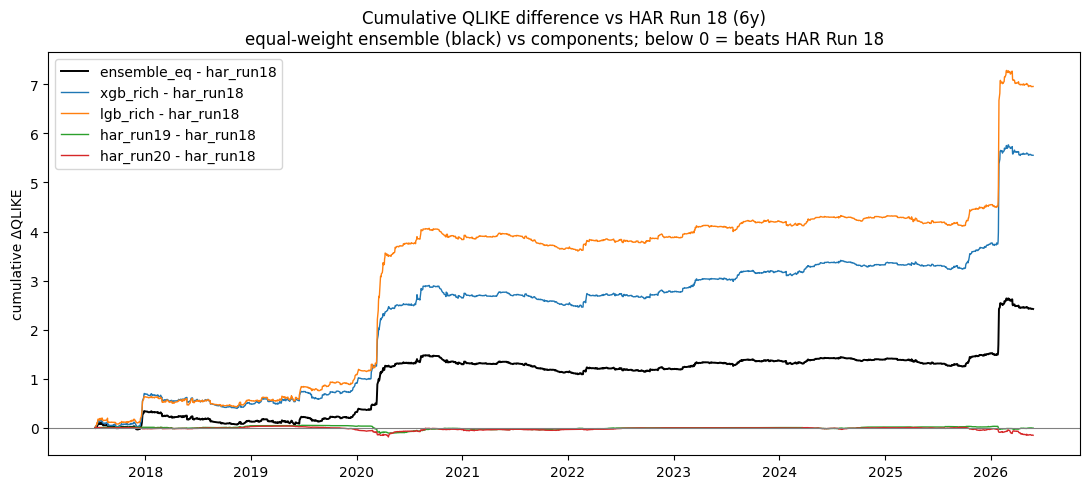

In [8]:
# ===========================================================================
# Cell 8 — Cumulative QLIKE difference vs HAR Run 18 (below 0 = beats run18)
# ===========================================================================
fig, ax = plt.subplots(figsize=(11, 5))
for name, color in [("ensemble_eq", "k"), ("xgb_rich", "C0"), ("lgb_rich", "C1"),
                    ("har_run19", "C2"), ("har_run20", "C3")]:
    ax.plot(losses.index, (losses[name] - losses["har_run18"]).cumsum(),
            label=f"{name} - har_run18", color=color, lw=1.4 if name == "ensemble_eq" else 1.0)
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Cumulative QLIKE difference vs HAR Run 18 (6y)\n"
             "equal-weight ensemble (black) vs components; below 0 = beats HAR Run 18")
ax.set_ylabel("cumulative \u0394QLIKE"); ax.legend()
fig.tight_layout(); fig.savefig("ensemble_cum_qlike_6y.png", dpi=150); plt.show()